# EDA

## Data Cleaning and Outlier Analysis

This will start off my analysis and be the foundation for my report. I first plan on doing some EDA to see how clean the data is and decide what to do with this data.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
raw_df = pd.read_csv("data/raw_data.csv")
raw_df.head(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [ ]:
# No missing values:
raw_df.isna().sum()

In [ ]:
#duplicates:
raw_df.duplicated()

In [8]:
raw_df.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

So taking a look at the columns, immediately four jump out as potential variables of interest/ response variables: sleep_duration_hours, sleep_quality_score, stress_level, and mental_fatigue_score

I will do a bit more exploration...

## EDA

### Response variables

In [ ]:
raw_df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


So it seems as though the variables that are classed on a numeric scale were read in as numeric variables... we could change it, but we could also use it as numeric... depends on what I end up doing with it.

Either way, let's start with some histograms of the four variables.

(array([ 650.,  722.,  982., 1143., 1293., 1270., 1322., 1224., 1327.,
        5067.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

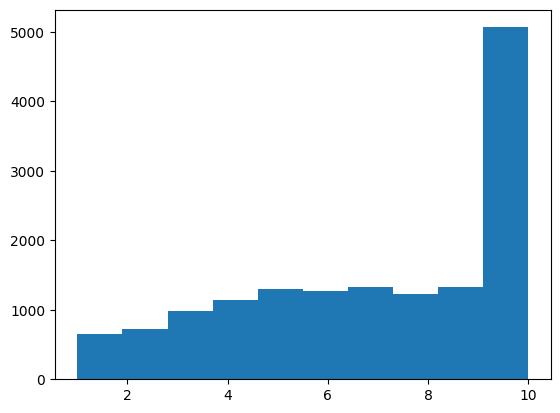

In [ ]:
#plt.hist(raw_df.sleep_duration_hours) #pretty even-- no tails or drastic imbalances

#plt.hist(raw_df.sleep_quality_score, color="black") 
# #generally expected... but there are class imbalances if we treat it as categorical

#plt.hist(raw_df.mental_fatigue_score) 
# really imbalanced... quite different from sleep quality score, so something else is going on

#plt.hist(raw_df.stress_level)
# I feel like I just replotted mental_fatigue_score... 
# really imbalanced, really high, not sure how representative this data is


So... I feel like the first two variables are generally representative of the general population... or at least of what I am aware... the later two seem to be a little biased (or maybe I am the one who is biased)

Now I will take a look at some key predictor variables that may be of interest.

#### Predictor Variables:

In [ ]:
# age